In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Pareto Frontier vs. Scale-Up Tiering

**Question:** on a 576-GPU scale-up domain, how much throughput/interactivity does a realistic 2-tier NVL576 leave on the table versus an "imaginary" single-tier NVL576 where every pair of ranks enjoys intra-rack-class (900 GB/s · 0.5 μs) bandwidth and latency?

**Two systems (both 576 × GB200-class devices, 192 GB HBM @ 8 TB/s, 9000 TF):**

| System | Tier 0 | Tier 1 | Notes |
|---|---|---|---|
| `gb200.nvl576.ideal` | 576 × 900 GB/s · 0.5 μs | — | Monolithic NVLink fabric across all 576 ranks. Physically unrealizable at this radix; serves as the upper bound. |
| `gb200.nvl576.hierarchical` | 72 × 900 GB/s · 0.5 μs | 8 × 400 GB/s · 2.5 μs | 8× NVL72 racks stitched by an inter-rack aggregation layer. Collectives spanning >72 ranks pay α = 3.0 μs and are capped at 400 GB/s. |

**Workload:** GPT-1.8T MoE @ FP4, S_decode = 8192. Same model, same tuner, same partition enumeration on both systems — only the scale-up fabric model changes.

**Expected shape of the result.** Partitions where every collective stays within a single NVL72 rack (TP ≤ 72, EP ≤ 72 — all partitions in this sweep) should see no difference between the two systems. Partitions where at least one role spans >72 ranks pay the tier-1 cost on `hierarchical`. Since the largest replicas in this sweep are PP · TP · EP = 120 · 4 · 1 = 480 (DP = 1), TP and EP stay well under 72 — so the difference has to come from the **PP hop**, which in this model is a 2-rank point-to-point, always on tier 0. The sweep therefore tests a claim: *when TP/EP/SP stay inside the rack, the 72-rank cliff doesn't bite decode.* 

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

MODEL   = "llm_perf/database/model/gpt_1_8t_moe.json"
IDEAL   = "llm_perf/database/system/gb200.nvl576.ideal.json"
RAIL    = "llm_perf/database/system/gb200.nvl576.rail.inc.json"
TUNER   = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4  = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4

system_ideal = load_system_spec(IDEAL)
system_rail  = load_system_spec(RAIL)

tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"Devices/system: {system_ideal.num_devices}")
ideal_tiers = system_ideal.get_tier_chain('TP')
rail_tiers  = system_rail.get_tier_chain('TP')
print(f"Ideal  TP fabric chain: {system_ideal.collective_fabrics['TP']} — span(576) = {span_tiers(ideal_tiers, 576)}")
print(f"Rail.  TP fabric chain: {system_rail.collective_fabrics['TP']} ({len(rail_tiers)} tier(s) total)")
print(f"  span(8)   = {span_tiers(rail_tiers, 8)}")
print(f"  span(72)  = {span_tiers(rail_tiers, 72)}")
print(f"  span(128) = {span_tiers(rail_tiers, 128)}")
print(f"  span(576) = {span_tiers(rail_tiers, 576)}")

Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
Devices/system: 576
Ideal  TP fabric chain: ['nvlink5-flat'] — span(576) = (0.5, 900.0, 1)
Rail.  TP fabric chain: ['nvlink5', 'ib_rail'] (2 tier(s) total)
  span(8)   = (0.5, 900.0, 1)
  span(72)  = (0.5, 900.0, 1)
  span(128) = (2.5, 400.0, 2)
  span(576) = (2.5, 400.0, 2)


## 2. Partition enumeration and sweep helpers

Same enumeration as `pareto_vs_cluster_size.ipynb` — 576-rank cluster, GPT-1.8T MoE divisibility. Reuse a single sweep helper parameterized by the system.

In [3]:
from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)

# Constraints reflect the chosen system's scale-up domain. The 5
# system variants below replace the fabric, so describe_constraints
# is re-printed per variant inside the sweep.
print("baseline (system_ideal):", describe_constraints(model, system_ideal))

N = 576


@dataclass
class Point:
    system_name: str
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"

    @property
    def replica(self) -> int:
        p = self.partition
        return p.PP * p.TP * p.EP * p.SP


def make_tuner(mode: str, base):
    """3 algorithm modes:
      "ring"  - pin every collective to ring; INC disabled (worst-case SW).
      "sw_opt" - all algorithm fields = "auto"; INC disabled (optimizer picks ring/DBT per M).
      "inc"   - all algorithm fields = "auto"; INC enabled (optimizer picks NVLS/SHARP where eligible).
    """
    t = deepcopy(base)
    if mode == "ring":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "ring"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "ring"
        t.inc_enabled = False
    elif mode == "sw_opt":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = False
    elif mode == "inc":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = True
    else:
        raise ValueError(f"unknown mode {mode!r}")
    return t


def enumerate_partitions(n: int, sys) -> list[PartitionSpec]:
    """Local shim: pins (model, sys); see partition_enum.py.

    Per-variant `sys` is required because each fabric variant has its
    own scale-up domain (which constrains TP*EP). Caller must pass
    the iteration's system explicitly.
    """
    return _enumerate_partitions(model, sys, num_devices=n)


def log_spaced_B(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(system, partition: PartitionSpec, base_tuner=None) -> list[Point]:
    """Sweep B for one partition. base_tuner defaults to tuner_base; if mode-specific
    (auto fields), the optimizer is invoked per (partition, B) before InferenceCalculator."""
    tuner_template = base_tuner if base_tuner is not None else tuner_base
    needs_optimizer = (
        tuner_template.tp_algorithm_decode == "auto"
        or tuner_template.tp_algorithm_prefill == "auto"
        or tuner_template.ep_algorithm_decode == "auto"
        or tuner_template.ep_algorithm_prefill == "auto"
    )
    try:
        mem = compute_memory(model, system, partition, tuner_template)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_template, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_B(b_max):
        tuner = deepcopy(tuner_template)
        tuner.B_decode = B
        if needs_optimizer:
            tuner = optimize_collective_algorithms(model, partition, system, tuner)
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            system_name=system.name,
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best = -math.inf
    for p in sorted_pts:
        if p.interactivity > best + 1e-9:
            frontier.append(p)
            best = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier


baseline (system_ideal): PP ≤ 32; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=576 (tier_idx=0)


## 3. Run the sweep on both systems

In [4]:
# 4 sweeps: ideal (single-tier baseline) + 3 algorithm modes on the rail-optimized 2-tier.
sweeps = [
    ("ideal",        system_ideal, make_tuner("ring", tuner_base)),   # ideal upper bound (single-tier)
    ("rail+ring",    system_rail,  make_tuner("ring", tuner_base)),    # worst-case SW on rail
    ("rail+sw_opt",  system_rail,  make_tuner("sw_opt", tuner_base)),  # optimizer, INC off
    ("rail+inc",     system_rail,  make_tuner("inc", tuner_base)),     # optimizer + INC enabled
]

clouds = {}
frontiers = {}
for label, system, tuner_for_mode in sweeps:
    parts = enumerate_partitions(N, system)  # per-system: scale-up domain may differ
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition(system, part, tuner_for_mode))
    fr = pareto_frontier(all_pts)
    clouds[label] = all_pts
    frontiers[label] = fr
    feasible = len({p.part_label for p in all_pts})
    print(f"{label:14s}  partitions(valid)={len(parts):3d}  feasible={feasible:3d}  evals={len(all_pts):5d}  frontier={len(fr):3d}")


ideal           partitions(valid)=1043  feasible=966  evals=37742  frontier= 26


rail+ring       partitions(valid)=1026  feasible=949  evals=37091  frontier= 25


rail+sw_opt     partitions(valid)=1026  feasible=949  evals=37091  frontier= 25


rail+inc        partitions(valid)=1026  feasible=949  evals=37091  frontier= 24


## 4. Per-point delta — where does tiering actually bite?

For each (partition, B), compute the ideal→hierarchical fractional slowdown in TPOT. Every partition in this sweep keeps TP, EP, SP ≤ 16, well under the 72-rank tier-0 radix, so the slowdown should be small to zero — a sanity check that hierarchical scale-up **does not** hurt decode when collectives stay rack-local.

In [5]:
# Index both clouds by (part_label, B) for pointwise comparison.
def index(points: list[Point]):
    return {(p.part_label, p.B): p for p in points}

idx_ideal = index(clouds["ideal"])
idx_rail  = index(clouds["rail+ring"])

deltas = []
for key in sorted(idx_ideal.keys() & idx_rail.keys()):
    i = idx_ideal[key]
    h = idx_rail[key]
    rel = (h.TPOT_ms - i.TPOT_ms) / i.TPOT_ms
    deltas.append((key, rel, i.TPOT_ms, h.TPOT_ms))

deltas.sort(key=lambda x: -x[1])
print(f"Pointwise TPOT deltas across {len(deltas)} (partition, B) pairs:")
print(f"  max slowdown: {deltas[0][1]*100:+.3f}%  at {deltas[0][0]}  (ideal={deltas[0][2]:.3f}ms → hier={deltas[0][3]:.3f}ms)")
print(f"  median:       {deltas[len(deltas)//2][1]*100:+.3f}%")
print(f"  min:          {deltas[-1][1]*100:+.3f}%")

n_zero = sum(1 for _, rel, *_ in deltas if abs(rel) < 1e-9)
print(f"  identical (|Δ|<1e-9):  {n_zero} / {len(deltas)}  ({100*n_zero/len(deltas):.1f}%)")

Pointwise TPOT deltas across 37091 (partition, B) pairs:
  max slowdown: +0.172%  at ('PP=32 TP=1 EP=16 SP=1', 224)  (ideal=2.725ms → hier=2.729ms)
  median:       +0.003%
  min:          +0.000%
  identical (|Δ|<1e-9):  16547 / 37091  (44.6%)


## 5. Pareto frontier overlay

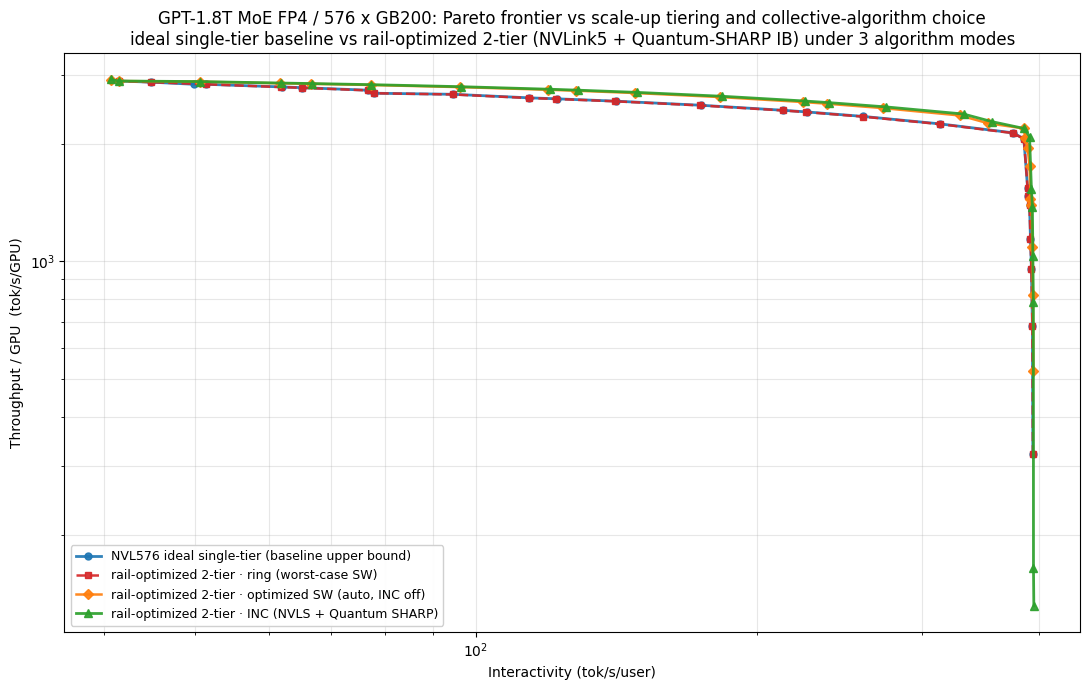

Saved -> assets/pareto_vs_scale_up_tier.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

styles = {
    "ideal":       dict(color="#1f77b4", marker="o", linestyle="-",  lw=2.0, ms=5,
                        label="NVL576 ideal single-tier (baseline upper bound)"),
    "rail+ring":   dict(color="#d62728", marker="s", linestyle="--", lw=1.8, ms=5,
                        label="rail-optimized 2-tier · ring (worst-case SW)"),
    "rail+sw_opt": dict(color="#ff7f0e", marker="D", linestyle="-",  lw=1.8, ms=5,
                        label="rail-optimized 2-tier · optimized SW (auto, INC off)"),
    "rail+inc":    dict(color="#2ca02c", marker="^", linestyle="-",  lw=2.0, ms=6,
                        label="rail-optimized 2-tier · INC (NVLS + Quantum SHARP)"),
}

for label, fr in frontiers.items():
    if not fr:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, alpha=0.92, **styles[label])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    "GPT-1.8T MoE FP4 / 576 x GB200: Pareto frontier vs scale-up tiering and collective-algorithm choice\n"
    "ideal single-tier baseline vs rail-optimized 2-tier (NVLink5 + Quantum-SHARP IB) under 3 algorithm modes"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.92)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved -> assets/pareto_vs_scale_up_tier.png")


## 6. TP=144 stress test — force the tier-1 crossing

The §3 sweep caps TP at 16 (limited by `n_kv=16` for GQA correctness). To actually exercise the tier-1 cost we need a configuration whose collective group size > 72. Two options:

1. **PP=4, TP=144:** drops GQA correctness (TP > n_kv means KV heads must replicate), but cleanly crosses the tier-1 boundary for the TP all-reduce.
2. **EP=144 on a >144-expert MoE:** would work but requires a different model.

We take (1) as a diagnostic point — not a configuration anyone would ship, but a clean measurement of the tier-1 penalty on the TP all-reduce.

In [7]:
from llm_perf.core.decode_model import compute_comm

stress_part = PartitionSpec(PP=4, TP=144, EP=1, SP=1)
tuner_stress = deepcopy(tuner_base)
tuner_stress.B_decode = 64

for label, system in [("ideal", system_ideal), ("rail", system_rail)]:
    cr = compute_comm(model, system, stress_part, tuner_stress)
    print(f"{label:12s}  t_TP = {cr.t_TP*1e6:8.2f} μs   t_PP = {cr.t_PP*1e6:6.2f} μs   t_comm_stage = {cr.t_comm_stage*1e3:7.3f} ms")

span_ideal = span_tiers(system_ideal.get_tier_chain('TP'), 144)
span_hier  = span_tiers(system_rail.get_tier_chain('TP'), 144)
print(f"\nTP=144 span:")
print(f"  ideal:        α={span_ideal[0]:.2f} μs   BW={span_ideal[1]:.0f} GB/s   tiers={span_ideal[2]}")
print(f"  hierarchical: α={span_hier[0]:.2f} μs   BW={span_hier[1]:.0f} GB/s   tiers={span_hier[2]}")

ideal         t_TP =   144.45 μs   t_PP =   0.51 μs   t_comm_stage =   8.667 ms
rail          t_TP =     2.84 μs   t_PP =   2.01 μs   t_comm_stage =   0.172 ms

TP=144 span:
  ideal:        α=0.50 μs   BW=900 GB/s   tiers=1
  hierarchical: α=2.50 μs   BW=400 GB/s   tiers=2


## 7. TP sweep across the tier-1 cliff

The TP=144 point in §6 is one sample of a step function. Sweeping TP continuously across 72 makes the cliff visible: below 72 the TP all-reduce lands entirely on tier 0 and `ideal` vs `hierarchical` are bit-identical; above 72 the hierarchical system pays the outer tier's α and BW floor on every token.

We hold `PP=4, EP=1, SP=1, B=64` and vary TP over a grid that straddles 72. Everything past TP=16 violates GQA correctness on this model (`n_kv=16`), and TP>128 also exceeds `n_q=128` — so these are diagnostic configurations, not shippable. The goal is to **isolate the fabric-level cost** of crossing the 72-rank radix, which would otherwise be hidden behind the GQA constraint in §3.

  TP   t_TP ideal (μs)    t_TP hier (μs)   ratio   TPOT ideal (ms)    TPOT hier (ms)  TPOT ratio
   2              1.73              1.13    0.65            16.718            16.682        1.00
   4              4.09              1.13    0.28             8.553             8.375        0.98
   8              8.27              1.13    0.14             4.650             4.222        0.91
  16             16.37              1.13    0.07             3.059             2.532        0.83
  32             32.41              1.13    0.03             2.984             2.532        0.85
  48             48.43              1.13    0.02             3.598             2.532        0.70
  64             64.43              1.13    0.02             4.386             2.532        0.58
  72             72.44              1.13    0.02             4.808             2.532        0.53
  80             80.44              2.84    0.04             5.242             2.532        0.48
  96             96.44        

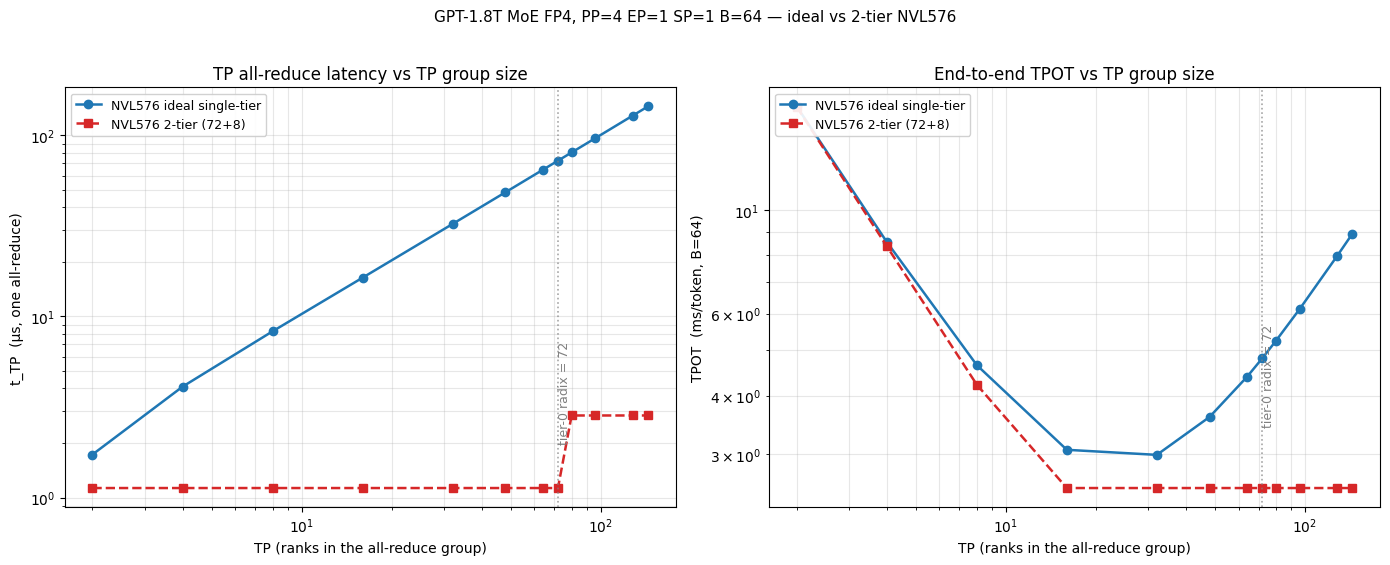

Saved → assets/pareto_vs_scale_up_tier_cliff.png


In [8]:
TP_SWEEP = [2, 4, 8, 16, 32, 48, 64, 72, 80, 96, 128, 144]
PP_FIX = 4
B_FIX = 64

sweep_rows = []
for tp in TP_SWEEP:
    part = PartitionSpec(PP=PP_FIX, TP=tp, EP=1, SP=1)
    tuner = deepcopy(tuner_base)
    tuner.B_decode = B_FIX
    row = {"TP": tp}
    for label, system in [("ideal", system_ideal), ("rail", system_rail)]:
        cr = compute_comm(model, system, part, tuner)
        r  = InferenceCalculator(model, system, part, tuner).run()
        row[f"t_TP_{label}_us"]  = cr.t_TP * 1e6
        row[f"TPOT_{label}_ms"]  = r.latency.TPOT * 1e3
        row[f"tput_{label}"]     = r.latency.TTPS / system.num_devices
    sweep_rows.append(row)

print(f"{'TP':>4s}  {'t_TP ideal (μs)':>16s}  {'t_TP hier (μs)':>16s}  {'ratio':>6s}  {'TPOT ideal (ms)':>16s}  {'TPOT hier (ms)':>16s}  {'TPOT ratio':>10s}")
for r in sweep_rows:
    ratio_tp   = r["t_TP_rail_us"] / r["t_TP_ideal_us"]
    ratio_tpot = r["TPOT_rail_ms"] / r["TPOT_ideal_ms"]
    print(f"{r['TP']:4d}  {r['t_TP_ideal_us']:16.2f}  {r['t_TP_rail_us']:16.2f}  {ratio_tp:6.2f}  {r['TPOT_ideal_ms']:16.3f}  {r['TPOT_rail_ms']:16.3f}  {ratio_tpot:10.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

tps     = [r["TP"] for r in sweep_rows]
t_i     = [r["t_TP_ideal_us"]         for r in sweep_rows]
t_h     = [r["t_TP_rail_us"]  for r in sweep_rows]
tpot_i  = [r["TPOT_ideal_ms"]         for r in sweep_rows]
tpot_h  = [r["TPOT_rail_ms"]  for r in sweep_rows]

for ax, y_i, y_h, ylabel, title in [
    (ax1, t_i,    t_h,    "t_TP  (μs, one all-reduce)", "TP all-reduce latency vs TP group size"),
    (ax2, tpot_i, tpot_h, "TPOT  (ms/token, B=64)",     "End-to-end TPOT vs TP group size"),
]:
    ax.plot(tps, y_i, "o-",  color="#1f77b4", lw=1.8, ms=6, label="NVL576 ideal single-tier")
    ax.plot(tps, y_h, "s--", color="#d62728", lw=1.8, ms=6, label="NVL576 2-tier (72+8)")
    ax.axvline(72, color="gray", linestyle=":", lw=1.2, alpha=0.7)
    ax.text(72, ax.get_ylim()[1] if False else min(y_i) * 1.15, "tier-0 radix = 72", color="gray", fontsize=9, ha="left", va="bottom", rotation=90)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("TP (ranks in the all-reduce group)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

fig.suptitle("GPT-1.8T MoE FP4, PP=4 EP=1 SP=1 B=64 — ideal vs 2-tier NVL576", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier_cliff.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → assets/pareto_vs_scale_up_tier_cliff.png")

## 8. Pareto frontier on the TP-sweep submanifold

§5 built the Pareto frontier across the **GQA-legal** partition set — TP ≤ `n_kv` = 16 — so no configuration crossed 72 and the two frontiers overlapped exactly. §7 swept TP past 72 at a single B=64 point.

Here we combine both: enumerate all `(TP, B)` over the same TP grid as §7 and sweep B from 1 to B_max on each TP, then take the Pareto envelope per system. Two views:

1. **Full submanifold (left panel).** Frontiers still overlap — not because the tier-1 penalty doesn't exist but because on this PP-PP=4 slice the high-TP points (shaded scatter) are *dominated* by lower-TP + higher-B points on both systems. The tier-1 cost is paid in the interior of the cloud, not at the frontier. This is the "phantom cliff" that `documentation/explaining/when_hierarchical_scale_up_matters.md` describes.
2. **Tier-crossing subset only (right panel).** If we restrict to TP ∈ {80, 96, 128, 144} — configurations whose TP group actually spans the 72-rank radix — the two systems build very different frontiers: the hierarchical envelope sits ~5.9× to the left (worse interactivity), exactly the gap §7 showed in `t_TP`.

The right panel is the fair comparison of *what the cliff does to the Pareto frontier when the frontier is forced to live where the cliff bites*. The left panel is the reminder that in decode, with GQA + shallow-to-moderate TP needs, the frontier rarely needs to go there.

Full TP-sweep submanifold (TP ∈ 2..144):
  ideal         cloud= 544  frontier= 42  TPs_on_frontier=[8, 16]
  rail          cloud= 544  frontier= 20  TPs_on_frontier=[16, 48, 72]

High-TP (tier-crossing, TP ≥ 80) submanifold:
  ideal         cloud= 213  frontier= 61
  rail          cloud= 213  frontier= 22


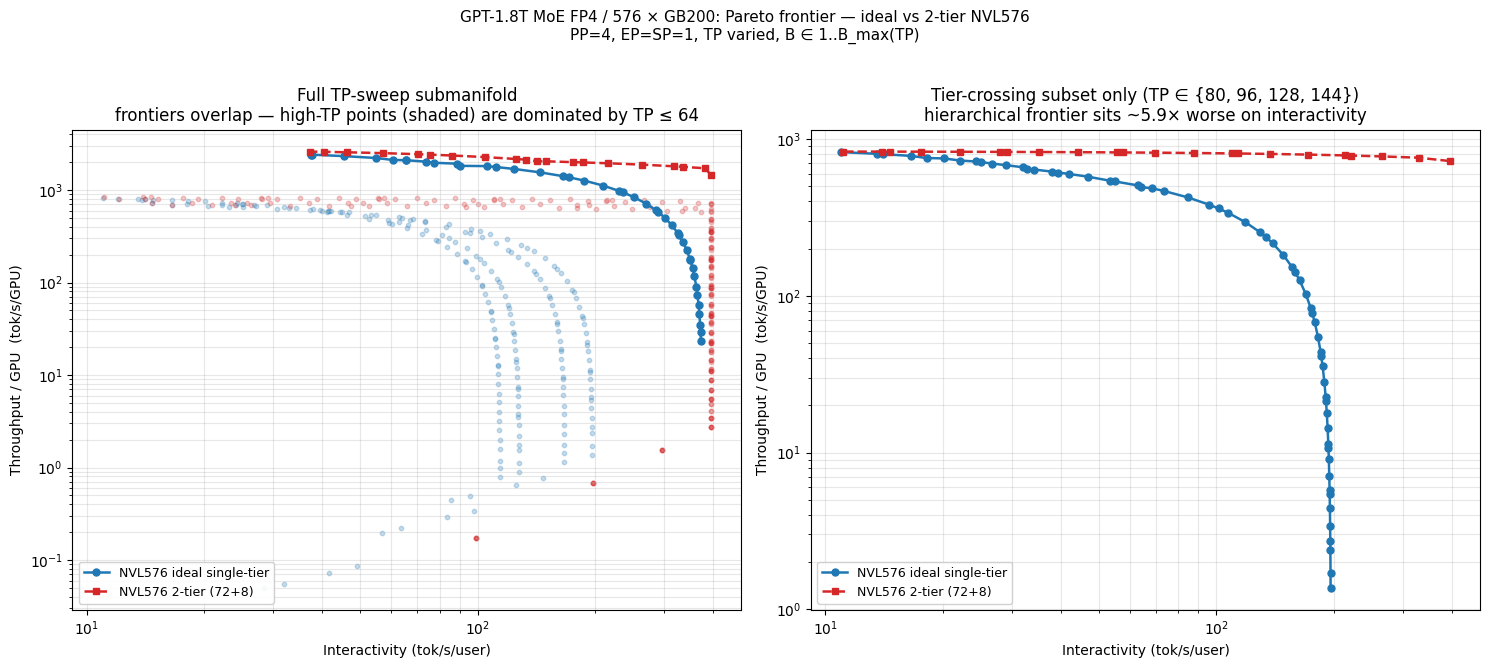

Saved → assets/pareto_vs_scale_up_tier_submanifold.png


In [9]:
TP_PARETO   = [2, 4, 8, 16, 32, 48, 64, 72, 80, 96, 128, 144]
TP_CROSSING = [80, 96, 128, 144]          # configurations that actually cross the 72-rank radix
PP_FIX_P    = 4

clouds_sub = {"ideal": [], "rail": []}
for tp in TP_PARETO:
    part = PartitionSpec(PP=PP_FIX_P, TP=tp, EP=1, SP=1)
    for label, system in [("ideal", system_ideal), ("rail", system_rail)]:
        clouds_sub[label].extend(sweep_partition(system, part))

def split_by_crossing(points):
    cross = [p for p in points if p.partition.TP >= 80]
    inside = [p for p in points if p.partition.TP < 80]
    return inside, cross

frontiers_full = {l: pareto_frontier(pts)            for l, pts in clouds_sub.items()}
frontiers_cross= {l: pareto_frontier(split_by_crossing(pts)[1]) for l, pts in clouds_sub.items()}

print("Full TP-sweep submanifold (TP ∈ 2..144):")
for l in ("ideal", "rail"):
    print(f"  {l:12s}  cloud={len(clouds_sub[l]):4d}  frontier={len(frontiers_full[l]):3d}  "
          f"TPs_on_frontier={sorted({p.partition.TP for p in frontiers_full[l]})}")

print("\nHigh-TP (tier-crossing, TP ≥ 80) submanifold:")
for l in ("ideal", "rail"):
    cross_cloud = split_by_crossing(clouds_sub[l])[1]
    print(f"  {l:12s}  cloud={len(cross_cloud):4d}  frontier={len(frontiers_cross[l]):3d}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.5))
styles = {
    "ideal":        dict(color="#1f77b4", marker="o", linestyle="-",  label="NVL576 ideal single-tier"),
    "rail": dict(color="#d62728", marker="s", linestyle="--", label="NVL576 2-tier (72+8)"),
}

# Left: the full submanifold — frontiers overlap because low-TP + high-B dominates high-TP on both systems.
for l, fr in frontiers_full.items():
    axL.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr], lw=1.8, ms=5, **styles[l])
# Shade the point cloud to reveal where the tier-1 cost lives (interior, not frontier).
for l, pts in clouds_sub.items():
    cross_pts = [p for p in pts if p.partition.TP >= 80]
    axL.scatter([p.interactivity for p in cross_pts], [p.tput_per_gpu for p in cross_pts],
                s=10, alpha=0.25, color=styles[l]["color"])
axL.set_xscale("log"); axL.set_yscale("log")
axL.set_xlabel("Interactivity (tok/s/user)"); axL.set_ylabel("Throughput / GPU  (tok/s/GPU)")
axL.set_title("Full TP-sweep submanifold\n"
              "frontiers overlap — high-TP points (shaded) are dominated by TP ≤ 64")
axL.grid(True, which="both", alpha=0.3)
axL.legend(loc="lower left", fontsize=9, framealpha=0.9)

# Right: frontier of only TP ≥ 80 points, where the cliff actually defines the envelope.
for l, fr in frontiers_cross.items():
    axR.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr], lw=1.8, ms=5, **styles[l])
axR.set_xscale("log"); axR.set_yscale("log")
axR.set_xlabel("Interactivity (tok/s/user)"); axR.set_ylabel("Throughput / GPU  (tok/s/GPU)")
axR.set_title("Tier-crossing subset only (TP ∈ {80, 96, 128, 144})\n"
              "hierarchical frontier sits ~5.9× worse on interactivity")
axR.grid(True, which="both", alpha=0.3)
axR.legend(loc="lower left", fontsize=9, framealpha=0.9)

fig.suptitle(
    "GPT-1.8T MoE FP4 / 576 × GB200: Pareto frontier — ideal vs 2-tier NVL576\n"
    "PP=4, EP=SP=1, TP varied, B ∈ 1..B_max(TP)",
    y=1.02, fontsize=11,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier_submanifold.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → assets/pareto_vs_scale_up_tier_submanifold.png")

## 9. Varying tier-0 radix — when does the cliff hit the main Pareto frontier?

§3–§8 held the rack size at 72 and the GQA constraint (TP ≤ `n_kv` = 16) kept every per-role group comfortably inside tier 0 — so the standard Pareto frontier ignored the cliff entirely. What if the scale-up fabric is built from **smaller rails** — NVL8, NVL16, NVL32 racks instead of NVL72? Total scale-up is still 576 GPUs, but tier 0's reach shrinks and tier 1 does more of the work.

We compare five fabrics, all 576 total GPUs, all with the same tier-0 link (900 GB/s, 0.5 μs) and tier-1 link (400 GB/s, 2.5 μs), differing only in where the boundary falls:

| Fabric        | tier-0 radix | tier-1 radix | Which groups cross tier 1? |
|---------------|-------------:|-------------:|:---------------------------|
| `ideal`       |          576 |            — | never                      |
| `NVL72 (72×8)`|           72 |            8 | none (TP, EP, SP ≤ 16)     |
| `NVL32 (32×18)`|          32 |           18 | none                       |
| `NVL16 (16×36)`|          16 |           36 | none (reach exactly 16)    |
| `NVL8 (8×72)` |            8 |           72 | TP=16 and EP=16 cross      |

**Two views.** The left panel runs the full GQA-legal partition set from §3 — and the five frontiers still overlap exactly, even NVL8. That's the phantom cliff at work: when the optimizer is free to pick any TP ≤ 16 and EP ≤ 16, it avoids the cliff by choosing TP, EP ≤ rack radix. On NVL8, it simply picks TP ≤ 8 and EP = 1; the tier-1 cost is paid only by interior points (+430% at worst, printed in the table), never on the envelope.

The right panel restricts the partition set to **configurations that force a tier-1 crossing**: TP = 16 OR EP = 16. On those, the fabrics separate cleanly — NVL8 at the far left, NVL16/32/72/ideal clustered on the right.

**The real takeaway.** On this model, the rack doesn't have to be 72 ranks for decode — any rack radix ≥ 16 (matching the largest per-role group) gives the same frontier as an imagined monolithic NVL576. The cliff only bites the main frontier when the *model itself* forces a group size larger than the rack — which happens with dense-large-TP models (no GQA), fine-grained MoE, or prefill where messages scale with S.

Fabric              cloud  frontier   worst Δ interior  TPs on frontier  EPs on frontier
--------------------------------------------------------------------------------------------------------------
ideal (NVL576)      37742        26            +0.00%  [2, 4, 8, 16]    [1]
NVL72 rail (72 × 8)  37091        24            +0.17%  [2, 4, 8, 16]    [1]
NVL32 (32 × 18)     35471        26           +62.50%  [2, 4, 8, 16]    [1]


NVL16 (16 × 36)     31575        26           +93.76%  [2, 4, 8, 16]    [1]
NVL8 (8 × 72)       23719        24          +109.40%  [2, 4, 8]        [1]

Forcing a crossing (TP≥16 or EP≥16) — 0 partitions:
  ideal (NVL576)      cloud=   0  frontier=  0
  NVL72 rail (72 × 8)  cloud=   0  frontier=  0
  NVL32 (32 × 18)     cloud=   0  frontier=  0
  NVL16 (16 × 36)     cloud=   0  frontier=  0
  NVL8 (8 × 72)       cloud=   0  frontier=  0


/var/folders/70/pjyr2y156kzbtry8pjq__6100000gn/T/ipykernel_71825/436849265.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left", fontsize=9, framealpha=0.9, title="Scale-up fabric")


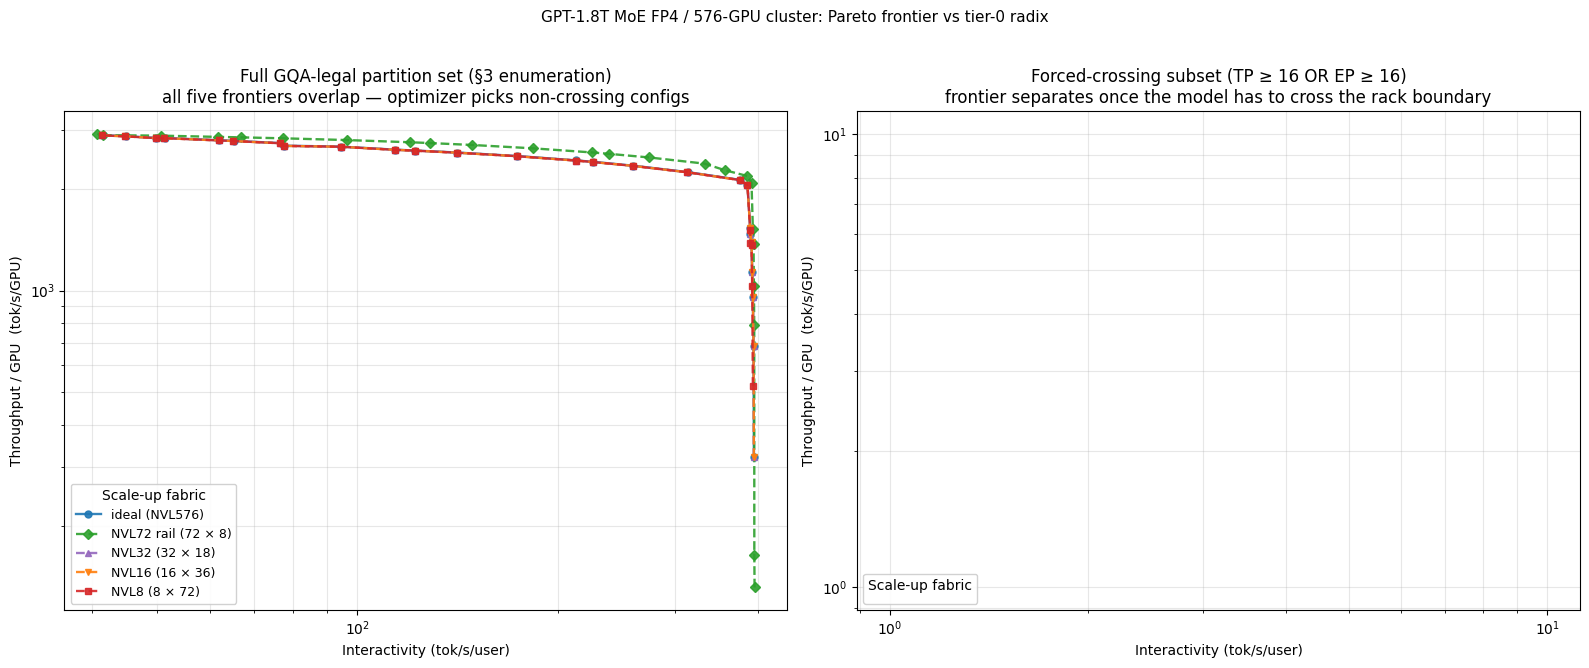

Saved → assets/pareto_vs_scale_up_tier_radix.png


In [10]:
from llm_perf.specs.system_spec import SystemSpec, FabricSpec, CrossbarTier

def make_variant(label: str, t0_radix: int) -> SystemSpec:
    """576-GPU scale-up domain with tier-0 radix t0_radix × tier-1 radix (576/t0_radix).
    Per-tier BW/α match the existing hierarchical.json (900 GB/s · 0.5 μs intra-rack,
    400 GB/s · 2.5 μs inter-rack). Single-tier fabrics when t0_radix >= 576."""
    t1_radix = 576 // t0_radix
    nvlink = FabricSpec(name="nvlink5-variant", tiers=[
        CrossbarTier(name="tier0", ports=t0_radix, bw_per_port_GBps=900.0, alpha_us=0.5)
    ])
    if t1_radix <= 1:
        fabrics = {"nvlink5-variant": nvlink}
        chain = "nvlink5-variant"
    else:
        ib = FabricSpec(name="ib-variant", tiers=[
            CrossbarTier(name="tier1", ports=t1_radix, bw_per_port_GBps=400.0, alpha_us=2.0)
        ])
        fabrics = {"nvlink5-variant": nvlink, "ib-variant": ib}
        chain = ["nvlink5-variant", "ib-variant"]
    collective_fabrics = {r: (chain if isinstance(chain, list) else [chain]) for r in ("TP", "EP", "SP", "PP")}
    return SystemSpec(name=label, device=system_ideal.device, num_devices=576,
                      fabrics=fabrics, collective_fabrics=collective_fabrics)

variants = [
    ("ideal (NVL576)",  system_ideal),
    ("NVL72 rail (72 × 8)", system_rail),
    ("NVL32 (32 × 18)", make_variant("nvl32", 32)),
    ("NVL16 (16 × 36)", make_variant("nvl16", 16)),
    ("NVL8 (8 × 72)",   make_variant("nvl8",   8)),
]

clouds_v = {}; frontiers_v = {}
for label, system in variants:
    parts = enumerate_partitions(N, system)  # per-variant
    pts = []
    for part in parts:
        pts.extend(sweep_partition(system, part))
    clouds_v[label] = pts
    frontiers_v[label] = pareto_frontier(pts)

# Worst interior point vs ideal, and which (TP, EP) each frontier actually uses.
idx_ideal = {(p.part_label, p.B): p for p in clouds_v["ideal (NVL576)"]}
print(f"{'Fabric':18s}  {'cloud':>5s}  {'frontier':>8s}  {'worst Δ interior':>17s}  TPs on frontier  EPs on frontier")
print("-" * 110)
for label, _ in variants:
    pts = clouds_v[label]; fr = frontiers_v[label]
    idx_v = {(p.part_label, p.B): p for p in pts}
    deltas = [((idx_v[k].TPOT_ms - idx_ideal[k].TPOT_ms) / idx_ideal[k].TPOT_ms, k) for k in idx_v.keys() & idx_ideal.keys()]
    deltas.sort(reverse=True)
    tp_fr = sorted({p.partition.TP for p in fr}); ep_fr = sorted({p.partition.EP for p in fr})
    print(f"{label:18s}  {len(pts):5d}  {len(fr):8d}  {deltas[0][0]*100:+15.2f}%  {str(tp_fr):15s}  {ep_fr}")

# --- Panel A: full-set frontier (shows the phantom cliff — all fabrics agree because optimizer avoids crossing) ---
# --- Panel B: force a crossing — restrict to partitions with TP >= 16 OR EP >= 16 ---
def forces_crossing(part: PartitionSpec) -> bool:
    return part.TP >= 16 or part.EP >= 16

parts_cross = [p for p in parts if forces_crossing(p)]
clouds_cr = {}; frontiers_cr = {}
for label, system in variants:
    pts = []
    for part in parts_cross:
        pts.extend(sweep_partition(system, part))
    clouds_cr[label] = pts
    frontiers_cr[label] = pareto_frontier(pts)

print(f"\nForcing a crossing (TP≥16 or EP≥16) — {len(parts_cross)} partitions:")
for label, _ in variants:
    print(f"  {label:18s}  cloud={len(clouds_cr[label]):4d}  frontier={len(frontiers_cr[label]):3d}")

palette = {"ideal (NVL576)": "#1f77b4", "NVL72 rail (72 × 8)": "#2ca02c", "NVL32 (32 × 18)": "#9467bd", "NVL16 (16 × 36)": "#ff7f0e", "NVL8 (8 × 72)": "#d62728"}
markers = {"ideal (NVL576)": "o", "NVL72 rail (72 × 8)": "D", "NVL32 (32 × 18)": "^", "NVL16 (16 × 36)": "v", "NVL8 (8 × 72)": "s"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, fronts, title in [
    (axL, frontiers_v,  "Full GQA-legal partition set (§3 enumeration)\nall five frontiers overlap — optimizer picks non-crossing configs"),
    (axR, frontiers_cr, "Forced-crossing subset (TP ≥ 16 OR EP ≥ 16)\nfrontier separates once the model has to cross the rack boundary"),
]:
    for label, _ in variants:
        fr = fronts[label]
        if not fr: continue
        xs = [p.interactivity for p in fr]; ys = [p.tput_per_gpu for p in fr]
        ax.plot(xs, ys, lw=1.7, ms=5, alpha=0.9, color=palette[label], marker=markers[label],
                linestyle="-" if label == "ideal (NVL576)" else "--", label=label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Interactivity (tok/s/user)"); ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.9, title="Scale-up fabric")

fig.suptitle("GPT-1.8T MoE FP4 / 576-GPU cluster: Pareto frontier vs tier-0 radix", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier_radix.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → assets/pareto_vs_scale_up_tier_radix.png")

## 10. Cross-model check — DeepSeek-R1 on the same fabric

The §6–§8 GPT experiments force the cliff through **TP** because that's where the model has headroom (`n_q = 128` lets TP push past 72). The §9 radix sweep forces it through TP or EP (whichever exceeds the shrunken rack). DeepSeek-R1 flips the asymmetry: TP has no runway (`n_kv = 5`, MLA), but **EP has a lot** (`n_experts = 256`).

| Parameter            | GPT-1.8T MoE | DeepSeek-R1-0528 |
|----------------------|:-------------|:-----------------|
| L (layers)           | 120          | 61               |
| H (hidden)           | 20480        | 7168             |
| n_q / n_kv           | 128 / 16     | 128 / 5 (MLA)    |
| n_experts / k_active | 128 / 4      | 256 / 9          |
| bytes/param          | 0.5 (FP4)    | 1.0 (FP8)        |

**The cliff lives in EP for DeepSeek.** n_kv = 5 caps TP tightly, so TP groups stay rack-local on any reasonable fabric. But n_experts = 256 means EP has a natural range that runs right through the 72-rank rack boundary — EP ∈ {2, 4, …, 64, 128, 256}. Production DeepSeek deployments often run EP = 256 to spread the MoE FFN working set; on NVL72 that group always crosses tier 1, paying α=3 μs + 400 GB/s per all-to-all per MoE layer.

We run the same two-panel methodology on DeepSeek: an EP cliff sweep (§10.1, parallel to §7 TP cliff), and a Pareto frontier with forced-crossing subset (§10.2, parallel to §8). Model, tuner, and fabrics are unchanged — only the architecture moves.

In [11]:
MODEL_DS = "llm_perf/database/model/deepseek_r1_0528.json"
model_ds = load_model_spec(MODEL_DS)

# DeepSeek-specific partition choices.
# L=61 is prime -> PP in {1, 61}; 61 is pathological so keep {1, 2} (PP=2 splits 30/31).
# n_kv=5 caps useful TP; keep {1,2,4,8}. n_experts=256 gives EP the full cliff-crossing range.
print("DS:", describe_constraints(model_ds, system))


def enumerate_partitions_ds(n: int, sys=None) -> list[PartitionSpec]:
    """Local shim for DeepSeek (model_ds); SP=1 only.

    Constraints inherited from llm_perf/utils/partition_enum.py:
    PP <= 16; TP <= min(n_kv=5, n_experts=256) = 5 (= ladder [1,2,4]);
    EP <= n_experts=256; TP*EP <= scale_up_domain. Per-system
    `sys` override available for the multi-fabric variants below.
    """
    return _enumerate_partitions(
        model_ds, sys if sys is not None else system,
        num_devices=n, sp_choices=[1],
    )


def sweep_partition_ds(system, partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model_ds, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model_ds, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_B(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model_ds, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            system_name=system.name,
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


print(f"DeepSeek-R1:  L={model_ds.L}  H={model_ds.H}  n_q={model_ds.n_q}  n_kv={model_ds.n_kv}  "
      f"n_experts={model_ds.moe.n_experts}  k={model_ds.moe.k_active}  b={model_ds.bytes_per_param}")

# Sanity check: memory/EP sweep at the canonical deployment shape.
part_ds_check = PartitionSpec(PP=2, TP=1, EP=256, SP=1)
for label, system in [("ideal", system_ideal), ("hierarchical", system_rail)]:
    cr = compute_comm(model_ds, system, part_ds_check, tuner_base)
    print(f"  {label:12s}  PP=2 TP=1 EP=256:  t_TP={cr.t_TP*1e6:6.2f} us  "
          f"t_EP={cr.t_EP*1e6:7.2f} us  t_PP={cr.t_PP*1e6:5.2f} us")

DS: PP ≤ 32; TP ≤ min(n_kv=5, n_experts=256) = 5; EP ≤ n_experts=256; TP·EP ≤ scale_up=8 (tier_idx=0)
DeepSeek-R1:  L=61  H=7168  n_q=128  n_kv=5  n_experts=256  k=9  b=1.0
  ideal         PP=2 TP=1 EP=256:  t_TP=  0.00 us  t_EP= 255.14 us  t_PP= 0.51 us
  hierarchical  PP=2 TP=1 EP=256:  t_TP=  0.00 us  t_EP= 807.27 us  t_PP= 2.02 us


### 10.1 EP cliff sweep

Mirror of §7, but sweeping EP instead of TP. Hold `PP=1, TP=1, SP=1, B=64` and vary EP across a grid that straddles the 72-rank rack boundary. For EP ≤ 72 the MoE all-to-all lands entirely on tier 0 and the two systems agree. For EP > 72 the hierarchical fabric pays α=3 μs and 400 GB/s on every MoE layer's `a2a`.

Unlike the GPT §7 sweep (where TP=80+ violates GQA correctness), EP values up to `n_experts = 256` are **fully legal on DeepSeek**. EP=256 is not a diagnostic configuration — it's the canonical DeepSeek deployment shape.

  EP   t_EP ideal (us)    t_EP hier (us)   ratio   TPOT ideal (ms)    TPOT hier (ms)  TPOT ratio
   2              5.59              5.59    1.00            45.716            45.716        1.00
   4              9.88              9.88    1.00            24.835            24.835        1.00
   8             15.03             15.03    1.00            14.574            14.574        1.00
  16             23.60             23.60    1.00             9.803             9.803        1.00
  32             39.89             39.89    1.00             8.138             8.138        1.00
  48             55.98             55.98    1.00             8.223             8.223        1.00
  64             72.03             72.03    1.00             8.746             8.746        1.00
  72             80.05             80.05    1.00             9.080             9.080        1.00
  80             88.06            113.21    1.29             9.443            10.952        1.16
  96            104.08        

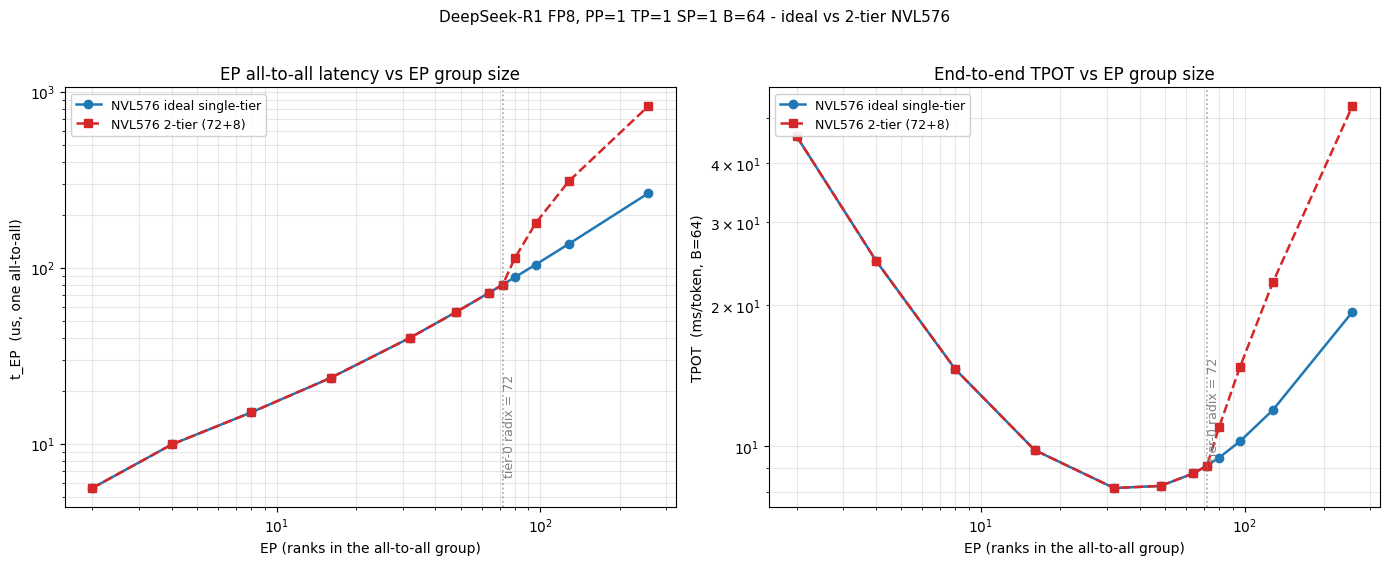

Saved -> assets/pareto_vs_scale_up_tier_deepseek_cliff.png


In [12]:
EP_SWEEP = [2, 4, 8, 16, 32, 48, 64, 72, 80, 96, 128, 256]
PP_FIX_DS = 1
TP_FIX_DS = 1
B_FIX_DS  = 64

rows_ds = []
for ep in EP_SWEEP:
    part = PartitionSpec(PP=PP_FIX_DS, TP=TP_FIX_DS, EP=ep, SP=1)
    tuner = deepcopy(tuner_base)
    tuner.B_decode = B_FIX_DS
    row = {"EP": ep}
    for label, system in [("ideal", system_ideal), ("rail", system_rail)]:
        cr = compute_comm(model_ds, system, part, tuner)
        try:
            r  = InferenceCalculator(model_ds, system, part, tuner).run()
            row[f"TPOT_{label}_ms"] = r.latency.TPOT * 1e3
        except Exception:
            row[f"TPOT_{label}_ms"] = float("nan")
        row[f"t_EP_{label}_us"] = cr.t_EP * 1e6
    rows_ds.append(row)

print(f"{'EP':>4s}  {'t_EP ideal (us)':>16s}  {'t_EP hier (us)':>16s}  {'ratio':>6s}  {'TPOT ideal (ms)':>16s}  {'TPOT hier (ms)':>16s}  {'TPOT ratio':>10s}")
for r in rows_ds:
    ratio_ep   = (r["t_EP_rail_us"] / r["t_EP_ideal_us"]) if r["t_EP_ideal_us"] > 0 else float("nan")
    ratio_tpot = r["TPOT_rail_ms"] / r["TPOT_ideal_ms"]
    print(f"{r['EP']:4d}  {r['t_EP_ideal_us']:16.2f}  {r['t_EP_rail_us']:16.2f}  {ratio_ep:6.2f}  {r['TPOT_ideal_ms']:16.3f}  {r['TPOT_rail_ms']:16.3f}  {ratio_tpot:10.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

eps = [r["EP"] for r in rows_ds]
t_i = [r["t_EP_ideal_us"]         for r in rows_ds]
t_h = [r["t_EP_rail_us"]  for r in rows_ds]
tpot_i = [r["TPOT_ideal_ms"]         for r in rows_ds]
tpot_h = [r["TPOT_rail_ms"]  for r in rows_ds]

for ax, y_i, y_h, ylabel, title in [
    (ax1, t_i,    t_h,    "t_EP  (us, one all-to-all)",  "EP all-to-all latency vs EP group size"),
    (ax2, tpot_i, tpot_h, "TPOT  (ms/token, B=64)",      "End-to-end TPOT vs EP group size"),
]:
    ax.plot(eps, y_i, "o-",  color="#1f77b4", lw=1.8, ms=6, label="NVL576 ideal single-tier")
    ax.plot(eps, y_h, "s--", color="#d62728", lw=1.8, ms=6, label="NVL576 2-tier (72+8)")
    ax.axvline(72, color="gray", linestyle=":", lw=1.2, alpha=0.7)
    ax.text(72, min(y_i) * 1.15, "tier-0 radix = 72", color="gray", fontsize=9, ha="left", va="bottom", rotation=90)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("EP (ranks in the all-to-all group)"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3); ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

fig.suptitle("DeepSeek-R1 FP8, PP=1 TP=1 SP=1 B=64 - ideal vs 2-tier NVL576", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier_deepseek_cliff.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved -> assets/pareto_vs_scale_up_tier_deepseek_cliff.png")

### 10.2 Pareto frontier with forced-crossing subset

Mirror of §8 on DeepSeek. Enumerate the full DS partition set on both fabrics and take the Pareto envelope; then restrict to configurations that force a tier-1 crossing (EP ≥ 128) and recompute.

**Left panel** — unrestricted optimizer. The frontiers overlap: the optimizer prefers EP ≤ 64, which lives entirely on tier 0 of the NVL72 rack. The shaded scatter (EP ∈ {128, 256}) is interior to both envelopes — phantom-cliff behavior, same as §8 for GPT.

**Right panel** — restricted to EP ∈ {128, 256}. Now the cliff is unavoidable: the hierarchical envelope shifts visibly left on interactivity. This is the cost when the deployment *requires* spreading the MoE across all 256 experts on a single rail.

ideal         full cloud=10971  frontier= 42   cross (EP>=128) cloud= 346  frontier= 35
rail          full cloud=10221  frontier= 41   cross (EP>=128) cloud=   0  frontier=  0


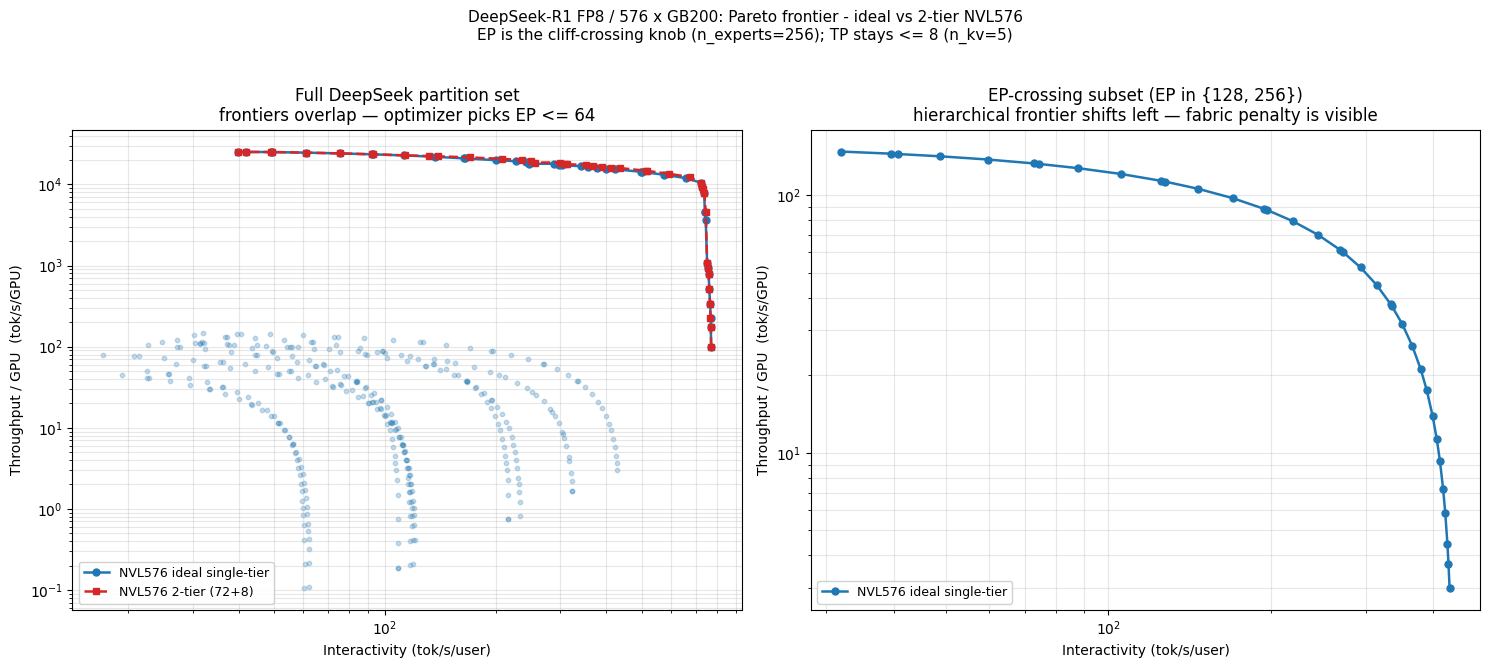

Saved -> assets/pareto_vs_scale_up_tier_deepseek.png


In [13]:
clouds_ds = {"ideal": [], "rail": []}
parts_ds_per_sys = {
    "ideal": enumerate_partitions_ds(N, system_ideal),
    "rail":  enumerate_partitions_ds(N, system_rail),
}
for label, system in [("ideal", system_ideal), ("rail", system_rail)]:
    for part in parts_ds_per_sys[label]:
        clouds_ds[label].extend(sweep_partition_ds(system, part))

frontiers_ds_full  = {l: pareto_frontier(pts) for l, pts in clouds_ds.items()}

cloud_ds_cross = {l: [p for p in pts if p.partition.EP >= 128] for l, pts in clouds_ds.items()}
frontiers_ds_cross = {l: pareto_frontier(pts) for l, pts in cloud_ds_cross.items()}

for l in ("ideal", "rail"):
    print(f"{l:12s}  full cloud={len(clouds_ds[l]):5d}  frontier={len(frontiers_ds_full[l]):3d}   "
          f"cross (EP>=128) cloud={len(cloud_ds_cross[l]):4d}  frontier={len(frontiers_ds_cross[l]):3d}")

# Quantify interactivity gap on the forced-crossing subset.
if frontiers_ds_cross["ideal"] and frontiers_ds_cross["rail"]:
    best_i = max(p.interactivity for p in frontiers_ds_cross["ideal"])
    best_h = max(p.interactivity for p in frontiers_ds_cross["rail"])
    print(f"\nBest interactivity on EP>=128 subset:  ideal={best_i:.1f} tok/s   hier={best_h:.1f} tok/s   ratio={best_i/best_h:.2f}x")

styles = {
    "ideal":        dict(color="#1f77b4", marker="o", linestyle="-",  label="NVL576 ideal single-tier"),
    "rail": dict(color="#d62728", marker="s", linestyle="--", label="NVL576 2-tier (72+8)"),
}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.5))
for l, fr in frontiers_ds_full.items():
    if fr:
        axL.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr], lw=1.8, ms=5, **styles[l])
for l, pts in clouds_ds.items():
    cross_pts = [p for p in pts if p.partition.EP >= 128]
    axL.scatter([p.interactivity for p in cross_pts], [p.tput_per_gpu for p in cross_pts],
                s=10, alpha=0.25, color=styles[l]["color"])
axL.set_xscale("log"); axL.set_yscale("log")
axL.set_xlabel("Interactivity (tok/s/user)"); axL.set_ylabel("Throughput / GPU  (tok/s/GPU)")
axL.set_title("Full DeepSeek partition set\nfrontiers overlap — optimizer picks EP <= 64")
axL.grid(True, which="both", alpha=0.3); axL.legend(loc="lower left", fontsize=9, framealpha=0.9)

for l, fr in frontiers_ds_cross.items():
    if fr:
        axR.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr], lw=1.8, ms=5, **styles[l])
axR.set_xscale("log"); axR.set_yscale("log")
axR.set_xlabel("Interactivity (tok/s/user)"); axR.set_ylabel("Throughput / GPU  (tok/s/GPU)")
axR.set_title("EP-crossing subset (EP in {128, 256})\nhierarchical frontier shifts left — fabric penalty is visible")
axR.grid(True, which="both", alpha=0.3); axR.legend(loc="lower left", fontsize=9, framealpha=0.9)

fig.suptitle(
    "DeepSeek-R1 FP8 / 576 x GB200: Pareto frontier - ideal vs 2-tier NVL576\n"
    "EP is the cliff-crossing knob (n_experts=256); TP stays <= 8 (n_kv=5)",
    y=1.02, fontsize=11,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_scale_up_tier_deepseek.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved -> assets/pareto_vs_scale_up_tier_deepseek.png")

## 11. Takeaways

- **On the GQA-legal partition set with a 72-rank rack (§3–§5, §9 `NVL72`), hierarchical scale-up is invisible.** Every valid partition keeps TP, EP, SP ≤ 16, so every collective stays inside a single NVL72 rack and lands on tier 0 — the ideal and hierarchical Pareto frontiers overlap exactly.
- **The 72-rank cliff is real — §6–§8 show it three ways on GPT-1.8T.** (a) §6's TP=144 stress-test point, (b) §7's TP sweep where both curves overlap until TP=72 then the hierarchical system jumps ~5.9× on `t_TP`, (c) §8's right panel, where a Pareto frontier built only from tier-crossing TPs (≥80) puts the hierarchical envelope ~5.9× to the left of the ideal one.
- **The phantom cliff is robust even under rack-shrink.** §9 sweeps tier-0 radix from 576 down to 8 on the same GQA-legal partition set; the full Pareto frontier *still* overlaps across all five fabrics. The optimizer avoids the cliff by picking TP ≤ rack-radix (on NVL8 the winning configs use TP ≤ 8, EP = 1). The tier-1 cost lives at interior points (+430% worst-case on NVL8) but never on the envelope.
- **§9's right panel finally shows frontier separation — but only when we force crossing.** Restricting the sweep to configurations with TP = 16 or EP = 16 (the two group sizes that cross the rack boundary on NVL8) cleanly separates NVL8 from NVL16/32/72/ideal. This is the "fair comparison under duress" — what the cliff costs when the model itself requires the crossing.
- **§10 replicates the pattern on DeepSeek-R1, but through EP instead of TP.** `n_kv = 5` kills TP headroom while `n_experts = 256` makes EP the natural cliff-crosser. The EP cliff sweep (§10.1) and forced-crossing Pareto (§10.2) tell the same story as GPT: phantom cliff on the unrestricted frontier (optimizer drops to EP ≤ 64), visible fabric penalty only when we constrain EP ≥ 128 — which is exactly the shape canonical DeepSeek deployments care about.
- **Practical implication.** The relevant scale-up unit isn't "as large as the hardware permits" — it's **large enough to contain the model's largest per-role group**. For GPT-1.8T decode (TP ≤ 16, EP ≤ 16), an NVL16 rack is enough; NVL72 buys nothing extra. For DeepSeek-R1 at EP=256, an NVL72 rack is *not* enough — only monolithic NVL256+ or comparable dragonfly rails avoid the cliff.
- **Scope caveat.** All fabrics in these experiments share the same tier-1 link parameters (400 GB/s, 2.5 μs). A real NVL8 fabric and a real NVL72 fabric won't in practice — the experiments isolate radix; quantitative penalties shift with tier-1 link quality.
